<div style="text-align:center;">
    <img src="hsrm.png" width="200">
</div>

<div style="text-align:center; margin-top:40px;">

# Projektarbeit  
## Fabio Schwibinger  

<br>

### Analyse und Verarbeitung grundlegender Signale  
### im Zeit- und Frequenzbereich  

    

<br><br>

# Teilaufgabe 1: Eingangssignale erzeugen

In dieser Aufgabe werden grundlegende deterministische Signale mithilfe von Python erzeugt, visualisiert und analysiert. Ziel ist es, ein Verständnis für typische Signalformen wie Dirac-, Rechteck-, Dreieck- und Sinussignale im Zeitbereich zu entwickeln. Dabei werden die Eigenschaften der Signale hinsichtlich ihrer Form, Stetigkeit sowie ihres energetischen Verhaltens untersucht und dokumentiert.

## Diracimpuls

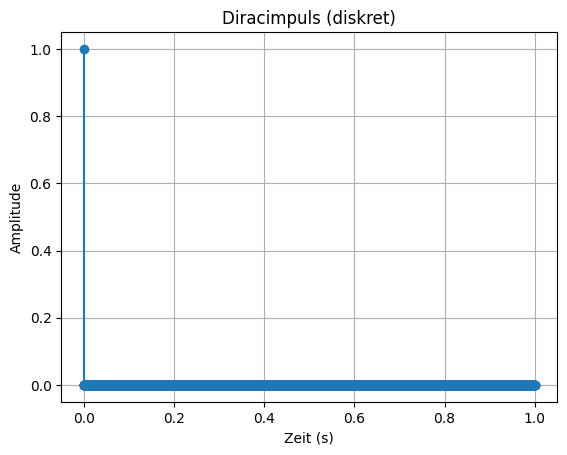

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter
fs = 5000  # Abtastrate
t = np.linspace(0, 1, fs, endpoint=False)

# Dirac-Impuls (digital approximiert)
x = np.zeros_like(t)
x[0] = 1   # Impuls am Anfang

# Plot
plt.figure()
plt.stem(t, x, basefmt=" ")
plt.title("Diracimpuls (diskret)")
plt.xlabel("Zeit (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

## Rechteckimpuls

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider

fs = 5000
t = np.linspace(0, 1, fs, endpoint=False)

def rechteck(A=1.0, pulse_width=0.1):
    x = np.zeros_like(t)

    N_pulse = int(pulse_width * fs)
    x[:N_pulse] = A

    plt.figure()
    plt.stem(t, x)
    plt.title("Rechteckimpuls (interaktiv)")
    plt.xlabel("Zeit (s)")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.ylim(-0.5, max(2, A + 1))
    plt.show()

interact(
    rechteck,
    A=FloatSlider(min=0, max=5, step=0.1, value=1),
    pulse_width=FloatSlider(min=0.01, max=0.5, step=0.01, value=0.1)
)

interactive(children=(FloatSlider(value=1.0, description='A', max=5.0), FloatSlider(value=0.1, description='pu…

<function __main__.rechteck(A=1.0, pulse_width=0.1)>

## Dreieckimpuls

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider

fs = 5000
t = np.linspace(0, 1, fs, endpoint=False)

def dreieck(A=1.0, pulse_width=0.2):
    x = np.zeros_like(t)

    N = int(pulse_width * fs)
    if N < 2:
        N = 2

    half = N // 2

    # Anstieg
    x[:half] = np.linspace(0, A, half)

    # Abfall
    x[half:N] = np.linspace(A, 0, N - half)

    # Plot
    plt.figure()
    plt.stem(t, x)
    plt.title("Dreieckimpuls (interaktiv)")
    plt.xlabel("Zeit (s)")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.ylim(-0.2, A + 0.5)
    plt.show()

interact(
    dreieck,
    A=FloatSlider(min=0, max=5, step=0.1, value=1),
    pulse_width=FloatSlider(min=0.01, max=0.5, step=0.01, value=0.2)
)

interactive(children=(FloatSlider(value=1.0, description='A', max=5.0), FloatSlider(value=0.2, description='pu…

<function __main__.dreieck(A=1.0, pulse_width=0.2)>

## Sinussignal

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider

fs = 5000
t = np.linspace(0, 1, fs, endpoint=False)

def sinus(A=1.0, f=100.0):
    x = A * np.sin(2 * np.pi * f * t)

    plt.figure()
    plt.plot(t, x)
    plt.title("Sinussignal (interaktiv)")
    plt.xlabel("Zeit (s)")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.ylim(-max(2, A + 0.5), max(2, A + 0.5))
    
    plt.show()

interact(
    sinus,
    A=FloatSlider(min=0, max=5, step=0.1, value=1),
    f=FloatSlider(min=50, max=2000, step=10, value=100)
)

interactive(children=(FloatSlider(value=1.0, description='A', max=5.0), FloatSlider(value=100.0, description='…

<function __main__.sinus(A=1.0, f=100.0)>

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider

fs = 10000
t = np.linspace(0, 1, fs, endpoint=False)

def sinus(A=1.0, f=100.0):
    x = A * np.sin(2 * np.pi * f * t)

    plt.figure()
    plt.plot(t, x)
    plt.title("Sinussignal (interaktiv stabilere Darstellung bei hohen Frequenzen)")
    plt.xlabel("Zeit (s)")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.ylim(-max(2, A + 0.5), max(2, A + 0.5))
    plt.xlim(0, 0.02)
    plt.show()

interact(
    sinus,
    A=FloatSlider(min=0, max=5, step=0.1, value=1),
    f=FloatSlider(min=50, max=2000, step=10, value=100)
)

interactive(children=(FloatSlider(value=1.0, description='A', max=5.0), FloatSlider(value=100.0, description='…

<function __main__.sinus(A=1.0, f=100.0)>

# Teilaufgabe 2: Analyse im Frequenzbereich

Die in Teilaufgabe 1 erzeugten Signale werden nun weiter untersucht und sowohl im Zeitbereich als auch im Frequenzbereich analysiert.

Zur Analyse im Frequenzbereich wird die Fast-Fourier-Transformation (FFT) verwendet, um die Amplituden- und Phasenspektren der einzelnen Signale zu bestimmen und miteinander zu vergleichen. Ziel der Aufgabe ist es, den Zusammenhang zwischen der Signalform im Zeitbereich und den daraus resultierenden Eigenschaften im Frequenzbereich besser zu verstehen.


# Diracimpuls

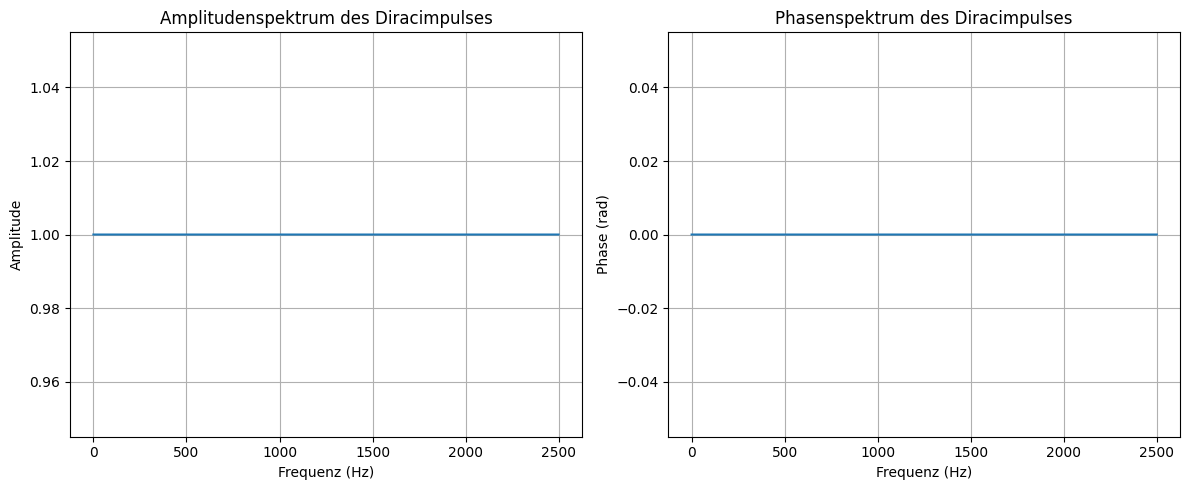

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter
fs = 5000
t = np.linspace(0, 1, fs, endpoint=False)
N = len(t)

# Diracimpuls
x = np.zeros(N)
x[0] = 1   # Impuls am anfang
# FFT berechnen
X = np.fft.fft(x)

# Frequenzachse
freq = np.fft.fftfreq(N, d=1/fs)

# Nur positive Frequenzen
half = N // 2

freq_half = freq[:half]
X_half = X[:half]

# Amplitudenspektrum
amplitude = np.abs(X_half)

# Phasenspektrum
phase = np.angle(X_half)

# Plot
plt.figure(figsize=(12,5))

# Amplitude
plt.subplot(1,2,1)
plt.plot(freq_half, amplitude)
plt.title("Amplitudenspektrum des Diracimpulses")
plt.xlabel("Frequenz (Hz)")
plt.ylabel("Amplitude")
plt.grid()

# Phase
plt.subplot(1,2,2)
plt.plot(freq_half, phase)
plt.title("Phasenspektrum des Diracimpulses")
plt.xlabel("Frequenz (Hz)")
plt.ylabel("Phase (rad)")
plt.grid()

plt.tight_layout()
plt.show()

Das dargestellte Amplitudenspektrum des Diracimpulses zeigt über den gesamten Frequenzbereich einen nahezu konstanten Wert. Dies bedeutet, dass der Diracimpuls alle Frequenzen mit gleicher Stärke enthält. Dieses Verhalten entspricht der theoretischen Eigenschaft des Diracimpulses aus der Signal- und Systemtheorie.

Da der Diracimpuls zeitlich extrem kurz ist und nur aus einem einzelnen Abtastwert besteht, besitzt er ein sehr breites Frequenzspektrum. Daraus lässt sich der Zusammenhang ableiten, dass kurze Signale im Zeitbereich breite Spektren im Frequenzbereich erzeugen.

Das Phasenspektrum zeigt über den gesamten Frequenzbereich einen konstanten Verlauf. Die Phase bleibt daher unverändert.

Der Diracimpuls enthält alle Frequenzanteile gleichzeitig und eignet sich deshalb besonders gut zur Untersuchung von Systemen und Filtern.

## Rechteckimpuls

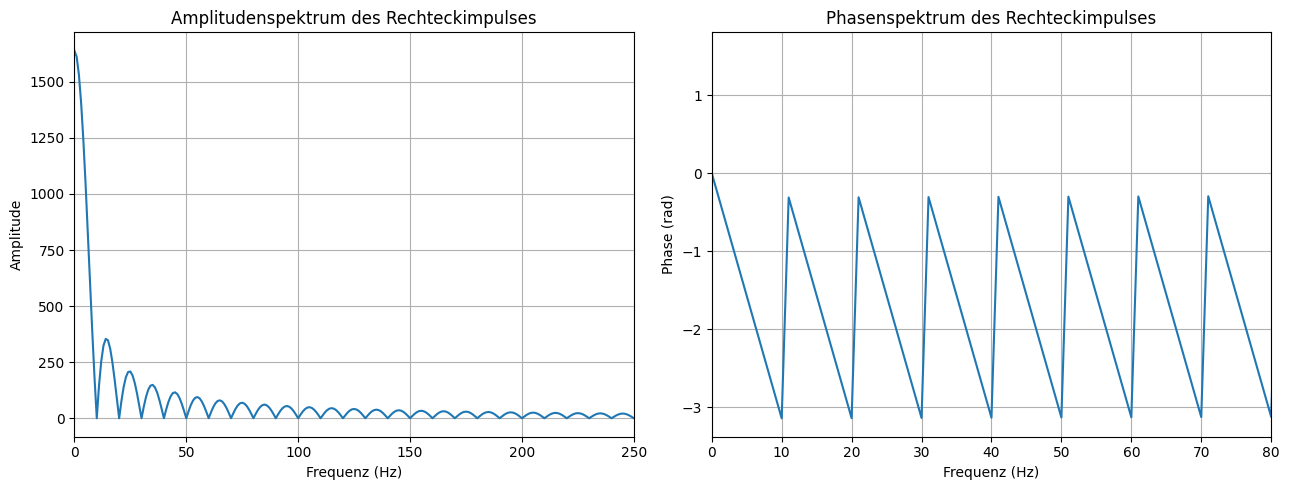

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter
fs = 16384
T = 1
N = fs * T

# Zeitachse
t = np.linspace(0, T, N, endpoint=False)

# Rechteckimpuls
x = np.zeros(N)

pulse_width = 0.1   # Pulsbreite in Sekunden
A = 1               # Amplitude

N_pulse = int(pulse_width * fs)
x[:N_pulse] = A

# FFT berechnen
X = np.fft.fft(x)

# Frequenzachse
freq = np.fft.fftfreq(N, d=1/fs)

# Nur positive Frequenzen
half = N // 2

freq_half = freq[:half]
X_half = X[:half]

# Amplituden- und Phasenspektrum
amplitude = np.abs(X_half)
phase = np.angle(X_half)

# Plot
plt.figure(figsize=(13,5))

# Amplitudenspektrum
plt.subplot(1,2,1)
plt.plot(freq_half, amplitude)
plt.xlim(0, 250)
plt.title("Amplitudenspektrum des Rechteckimpulses")
plt.xlabel("Frequenz (Hz)")
plt.ylabel("Amplitude")
plt.grid()

# Phasenspektrum
plt.subplot(1,2,2)
plt.plot(freq_half, phase)
plt.xlim(0, 80)
plt.title("Phasenspektrum des Rechteckimpulses")
plt.xlabel("Frequenz (Hz)")
plt.ylabel("Phase (rad)")
plt.grid()

plt.tight_layout()
plt.show()

Das Amplitudenspektrum des Rechteckimpulses zeigt einen hohen Anteil niedriger Frequenzen sowie mehrere abklingende Nebenmaxima. Die spektrale Form ähnelt einer Sinc-Funktion. Mit zunehmender Frequenz nimmt die Amplitude kontinuierlich ab.

Im Vergleich zum Diracimpuls besitzt der Rechteckimpuls ein schmaleres Spektrum, da das Signal im Zeitbereich eine größere Ausdehnung besitzt. Dennoch enthält das Signal weiterhin viele verschiedene Frequenzanteile. Besonders die abrupten Übergänge an den Flanken erzeugen hohe Frequenzkomponenten.

Das Phasenspektrum weist mehrere Phasensprünge auf. Diese entstehen durch die diskreten Übergänge des Rechtecksignals sowie durch die unterschiedlichen Phasenlagen der einzelnen Frequenzkomponenten.

## Dreieckimpuls

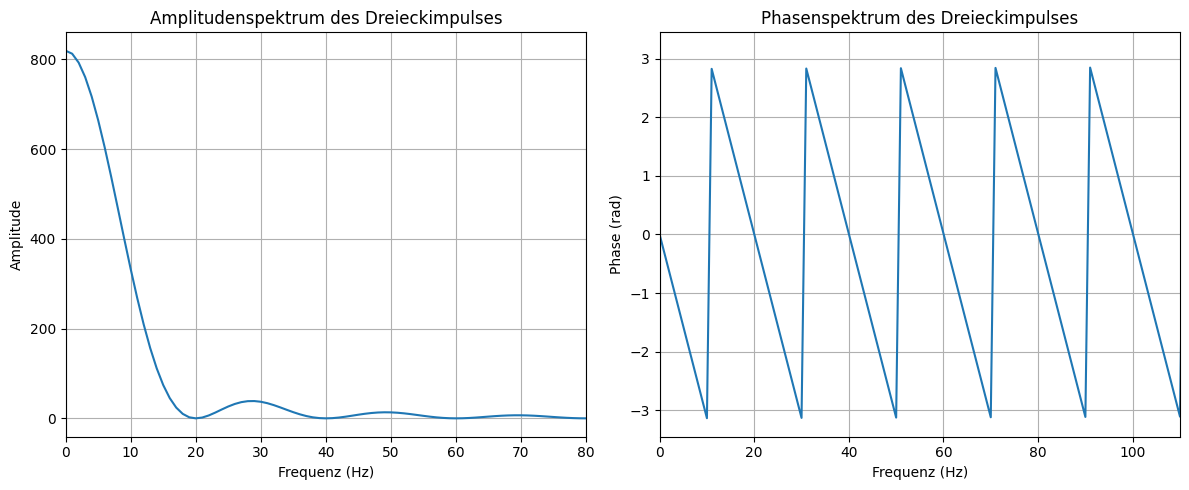

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter
fs = 16384
T = 1
N = fs * T

# Zeitachse
t = np.linspace(0, T, N, endpoint=False)

# Dreieckimpuls
x = np.zeros(N)

pulse_width = 0.1   # Pulsbreite
A = 1               # Amplitude

N_pulse = int(pulse_width * fs)
half_pulse = N_pulse // 2

# Linearer Anstieg
x[:half_pulse] = np.linspace(0, A, half_pulse)

# Linearer Abfall
x[half_pulse:N_pulse] = np.linspace(A, 0, N_pulse - half_pulse)

# FFT berechnen
X = np.fft.fft(x)

# Frequenzachse
freq = np.fft.fftfreq(N, d=1/fs)

# Nur positive Frequenzen
half = N // 2

freq_half = freq[:half]
X_half = X[:half]

# Amplituden- und Phasenspektrum
amplitude = np.abs(X_half)
phase = np.angle(X_half)

# Plot
plt.figure(figsize=(12,5))

# Amplitudenspektrum
plt.subplot(1,2,1)
plt.plot(freq_half, amplitude)
plt.xlim(0, 80)
plt.title("Amplitudenspektrum des Dreieckimpulses")
plt.xlabel("Frequenz (Hz)")
plt.ylabel("Amplitude")
plt.grid()

# Phasenspektrum
plt.subplot(1,2,2)
plt.plot(freq_half, phase)
plt.xlim(0, 110)
plt.title("Phasenspektrum des Dreieckimpulses")
plt.xlabel("Frequenz (Hz)")
plt.ylabel("Phase (rad)")
plt.grid()

plt.tight_layout()
plt.show()

Das Amplitudenspektrum des Dreieckimpulses enthält überwiegend niedrige Frequenzanteile. Im Vergleich zum Rechteckimpuls fällt das Spektrum deutlich schneller ab. Dies liegt daran, dass der Dreieckimpuls weichere und kontinuierliche Übergänge besitzt und dadurch weniger hohe Frequenzen erzeugt.

Während der Rechteckimpuls aufgrund seiner abrupten Flanken viele Oberwellen enthält, besitzt der Dreieckimpuls ein deutlich glatteres Frequenzverhalten. Dadurch konzentriert sich die Energie stärker auf niedrige Frequenzen.

Das Phasenspektrum zeigt ebenfalls Änderungen der Phase über den Frequenzbereich. Die Verläufe wirken jedoch regelmäßiger und weniger sprunghaft als beim Rechteckimpuls. Dies liegt an der symmetrischen und glatteren Signalform des Dreieckimpulses.

## Sinussignal

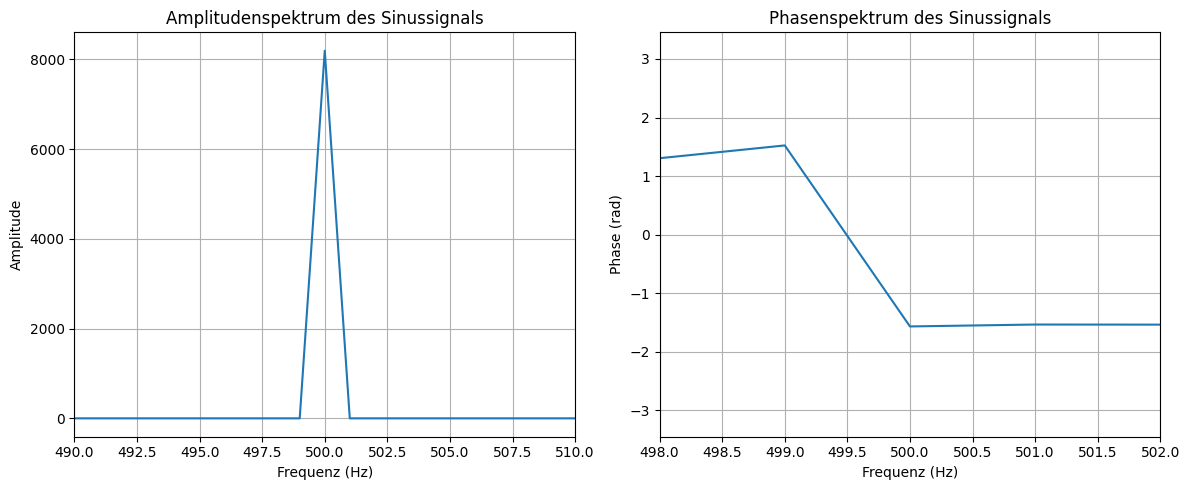

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter
fs = 16384
T = 1
N = fs * T

# Zeitachse
t = np.linspace(0, T, N, endpoint=False)

# Sinussignal
A = 1          # Amplitude
f0 = 500       # Frequenz in Hz

x = A * np.sin(2 * np.pi * f0 * t)

# FFT berechnen
X = np.fft.fft(x)

# Frequenzachse
freq = np.fft.fftfreq(N, d=1/fs)

# Nur positive Frequenzen
half = N // 2

freq_half = freq[:half]
X_half = X[:half]

# Amplitudenspektrum
amplitude = np.abs(X_half)

# Phasenspektrum
phase = np.angle(X_half)

# Plot
plt.figure(figsize=(12,5))

# Amplitudenspektrum
plt.subplot(1,2,1)
plt.plot(freq_half, amplitude)
plt.xlim(490, 510)
plt.title("Amplitudenspektrum des Sinussignals")
plt.xlabel("Frequenz (Hz)")
plt.ylabel("Amplitude")
plt.grid()

# Phasenspektrum
plt.subplot(1,2,2)
plt.plot(freq_half, phase)
plt.xlim(498, 502)
plt.title("Phasenspektrum des Sinussignals")
plt.xlabel("Frequenz (Hz)")
plt.ylabel("Phase (rad)")
plt.grid()

plt.tight_layout()
plt.show()

Das Amplitudenspektrum des Sinussignals zeigt einen deutlichen Peak bei der eingestellten Frequenz von 500 Hz. Dies bedeutet, dass das Signal nahezu ausschließlich aus einer einzelnen Frequenzkomponente besteht. Im Gegensatz zu den Impulssignalen besitzt das Sinussignal daher ein sehr schmales Frequenzspektrum.

Während Dirac-, Rechteck- und Dreieckimpulse viele verschiedene Frequenzanteile enthalten, konzentriert sich die Energie des Sinussignals auf eine einzige dominante Frequenz. Dadurch entsteht im Frequenzbereich lediglich eine markante Spektrallinie bei 500 Hz.

Das Phasenspektrum ist hauptsächlich im Bereich dieser dominanten Frequenz sinnvoll interpretierbar.
Im Bereich um 500 Hz erkennt man eine deutlich stabilere Phase. Dort liegt die eigentliche Frequenz des Sinussignals. Die Phase beträgt ungefähr −π/2.


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

# Grundparameter
fs = 5000
T = 1
N = fs * T
t = np.linspace(0, T, N, endpoint=False)

def fft_labor(signaltyp="Dirac", A=1.0, pulse_width=0.1, f0=500):
    
    # Signal erzeugen
    x = np.zeros(N)

    if signaltyp == "Dirac":
        x[N // 2] = A

    elif signaltyp == "Rechteck":
        N_pulse = int(pulse_width * fs)
        x[:N_pulse] = A

    elif signaltyp == "Dreieck":
        N_pulse = int(pulse_width * fs)
        half_pulse = N_pulse // 2

        x[:half_pulse] = np.linspace(0, A, half_pulse)
        x[half_pulse:N_pulse] = np.linspace(A, 0, N_pulse - half_pulse)

    elif signaltyp == "Sinus":
        x = A * np.sin(2 * np.pi * f0 * t)

    # FFT berechnen
    X = np.fft.fft(x)
    freq = np.fft.fftfreq(N, d=1/fs)

    # Nur positive Frequenzen
    half = N // 2
    freq_half = freq[:half]
    X_half = X[:half]

    amplitude = np.abs(X_half)
    phase = np.angle(X_half)
    # Plot
    plt.figure(figsize=(15,4))

    # Zeitbereich
    plt.subplot(1,3,1)
    plt.plot(t, x)
    plt.title("Zeitsignal")
    plt.xlabel("Zeit (s)")
    plt.ylabel("Amplitude")
    plt.grid()
    # Dynamischer Zoom für Sinus
    if signaltyp == "Sinus":
       periods = 5
       xmax = periods / f0
       plt.xlim(0, xmax)
    else:
       plt.xlim(0, 1)

    # Amplitudenspektrum
    plt.subplot(1,3,2)
    plt.plot(freq_half, amplitude)
    plt.title("Amplitudenspektrum")
    plt.xlabel("Frequenz (Hz)")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.xlim(0, 150)

    # Phasenspektrum
    plt.subplot(1,3,3)
    plt.plot(freq_half, phase)
    plt.title("Phasenspektrum")
    plt.xlabel("Frequenz (Hz)")
    plt.ylabel("Phase (rad)")
    plt.grid()
    plt.xlim(0, 100)

    plt.tight_layout()
    plt.show()

interact(
    fft_labor,
    signaltyp=widgets.Dropdown(
        options=["Dirac", "Rechteck", "Dreieck", "Sinus"],
        value="Dirac",
        description="Signal:"
    ),
    A=widgets.FloatSlider(
        min=0.1, max=5, step=0.1, value=1,
        description="Amplitude",
        continuous_update=False
    ),
    pulse_width=widgets.FloatSlider(
        min=0.01, max=0.5, step=0.01, value=0.1,
        description="Pulsbreite",
        continuous_update=False
    ),
    f0=widgets.FloatSlider(
        min=50, max=2000, step=10, value=500,
        description="Frequenz",
        continuous_update=False
    )
    
)

interactive(children=(Dropdown(description='Signal:', options=('Dirac', 'Rechteck', 'Dreieck', 'Sinus'), value…

<function __main__.fft_labor(signaltyp='Dirac', A=1.0, pulse_width=0.1, f0=500)>

# Teilaufgabe 3: Filterung der Eingangssignale


In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import ipywidgets as widgets
from ipywidgets import interact

# Parameter
fs = 16384
T = 1
N = fs * T
t = np.linspace(0, T, N, endpoint=False)

# Filterparameter
order = 4
cutoff_low = 300          # Tief-/Hochpassgrenze
band_low = 200            # untere Bandpassgrenze
band_high = 800           # obere Bandpassgrenze

# Signale
signals = {}

# Diracimpuls
x_dirac = np.zeros(N)
x_dirac[N // 2] = 1
signals["Diracimpuls"] = x_dirac

# Rechteckimpuls
x_rect = np.zeros(N)
pulse_width = 0.1
x_rect[:int(pulse_width * fs)] = 1
signals["Rechteckimpuls"] = x_rect

# Dreieckimpuls
x_tri = np.zeros(N)
pulse_width = 0.2
N_pulse = int(pulse_width * fs)
half_pulse = N_pulse // 2

x_tri[:half_pulse] = np.linspace(0, 1, half_pulse)
x_tri[half_pulse:N_pulse] = np.linspace(1, 0, N_pulse - half_pulse)
signals["Dreieckimpuls"] = x_tri

# Sinussignal
f0 = 500
x_sin = np.sin(2 * np.pi * f0 * t)
signals["Sinussignal 500 Hz"] = x_sin


def plot_signal(signal_name, filtertyp):

    x = signals[signal_name]

    # Filter auswählen
    if filtertyp == "Tiefpass":
        b, a = butter(
            order,
            cutoff_low / (fs / 2),
            btype='low'
        )

    elif filtertyp == "Hochpass":
        b, a = butter(
            order,
            cutoff_low / (fs / 2),
            btype='high'
        )

    elif filtertyp == "Bandpass":
        b, a = butter(
            order,
            [band_low / (fs / 2),
             band_high / (fs / 2)],
            btype='band'
        )

    # Filterung
    y = filtfilt(b, a, x)

    # FFT
    X = np.fft.fft(x)
    Y = np.fft.fft(y)

    # Frequenzachse
    freq = np.fft.fftfreq(N, d=1/fs)
    half = N // 2

    freq_half = freq[:half]

    # Amplitudenspektrum
    X_amp = np.abs(X[:half])
    Y_amp = np.abs(Y[:half])

    # Plot
    plt.figure(figsize=(14, 6))

    # Zeitbereich
    plt.subplot(1, 2, 1)
    plt.plot(t, x, label="Original")
    plt.plot(t, y, label="Gefiltert")

    plt.title(f"{signal_name} mit {filtertyp}")
    plt.xlabel("Zeit (s)")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.legend()
   # Zeitachse abhängig vom Signal
    # Individuelle Zeitachsen
    if signal_name == "Sinussignal 500 Hz":
        plt.xlim(0.10, 0.14)

    elif signal_name == "Rechteckimpuls":
        plt.xlim(0.08, 0.12)

    else:
        plt.xlim(0, 0.3)

    # Frequenzbereich
    plt.subplot(1, 2, 2)
    plt.plot(freq_half, X_amp, label="Original")
    plt.plot(freq_half, Y_amp, label="Gefiltert")

    plt.title(f"{signal_name} im Frequenzbereich")
    plt.xlabel("Frequenz (Hz)")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.legend()
   # Individuelle Frequenzachsen
    if signal_name in ["Rechteckimpuls", "Dreieckimpuls"]:
      plt.xlim(0, 400)
    else:
      plt.xlim(0, 1500)

    plt.tight_layout()
    plt.show()


interact(
    plot_signal,

    signal_name=widgets.Dropdown(
        options=list(signals.keys()),
        value="Diracimpuls",
        description="Signal:"
    ),

    filtertyp=widgets.Dropdown(
        options=["Tiefpass", "Hochpass", "Bandpass"],
        value="Tiefpass",
        description="Filter:"
    )
);

interactive(children=(Dropdown(description='Signal:', options=('Diracimpuls', 'Rechteckimpuls', 'Dreieckimpuls…

# Teilaufgabe 4: Modulation eines Sinusträgers 